## Preliminary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./UPL25_matches1.csv')

In [ ]:
df.shape

In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [ ]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled



In [ ]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [ ]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Executive Summary

In [ ]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity)

In [ ]:
summary_table_volume = df[volume_metrics].agg(['sum', 'max','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

## Data Overview

In [ ]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

In [ ]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

In [ ]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

In [ ]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

C:\Users\hnyanzi\AppData\Local\Temp\ipykernel_11192\2060886821.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)


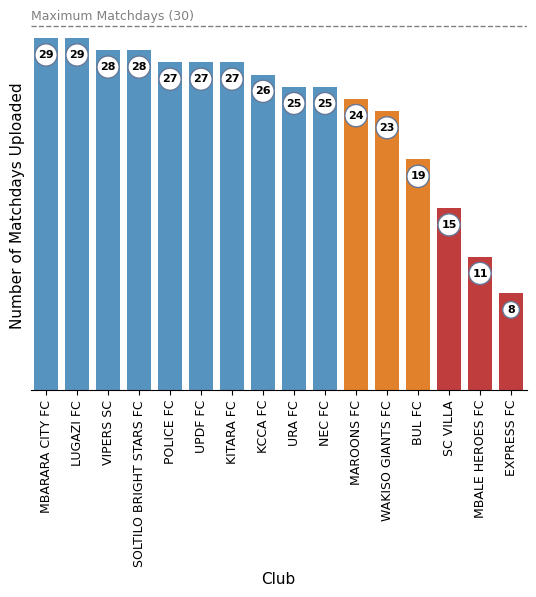

In [145]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding colors
def usage_tier_color(val):
    if val >= 25:
        return "#4596cf"  # dark blue for high engagement
    elif val >= 16:
        return '#ff7f0e'  # orange for medium
    else:
        return '#d62728'  # red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(data=data, x='club_for',hue='club_for', y='unique_matchdays', palette=colors,legend=False)

# Benchmark line at maximum matchdays (30)
plt.axhline(30, color='gray', linestyle='--', linewidth=1)
plt.text(-0.5, 30.5, 'Maximum Matchdays (30)', color='gray', fontsize=9)

# Rotate and uppercase x labels
ax = plt.gca()
ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)

# Title, subtitle, and axis labels
plt.xlabel('Club', fontsize=11)
plt.ylabel('Number of Matchdays Uploaded', fontsize=11)

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 1.8, str(value),
        ha='center', va='bottom',
        fontsize=8, color='black', fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.30", edgecolor='#667898', facecolor='white', linewidth=1)
    )
#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])


plt.show()


In [ ]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

In [ ]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


In [142]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)


    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(md).replace('Md', 'MD ') for md in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    # ax.set_ylim(bottom=60,top=180)  # Adjust the top limit as needed

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

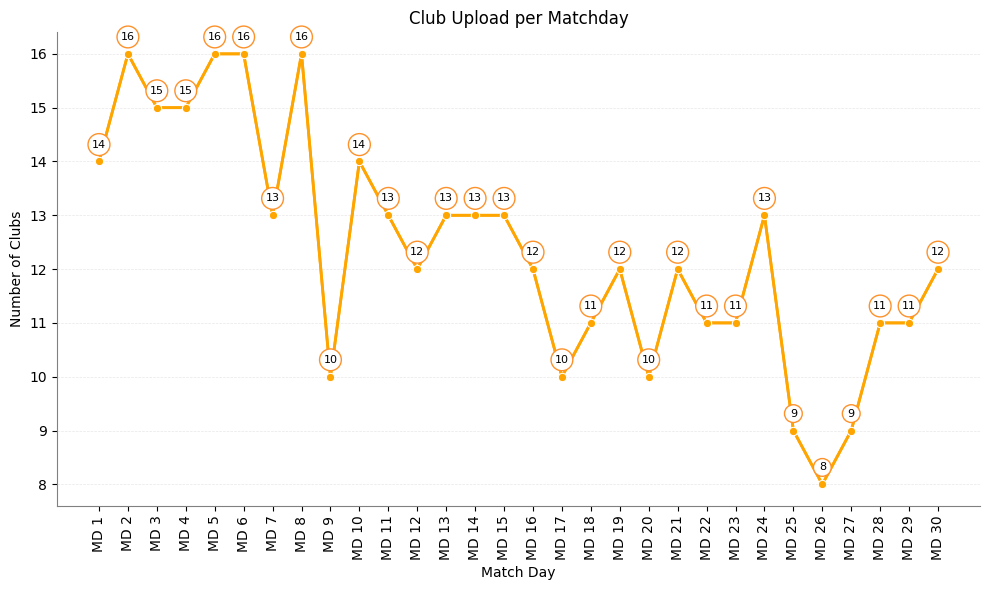

In [143]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Club Upload per Matchday', x_label='Match Day', y_label='Number of Clubs');

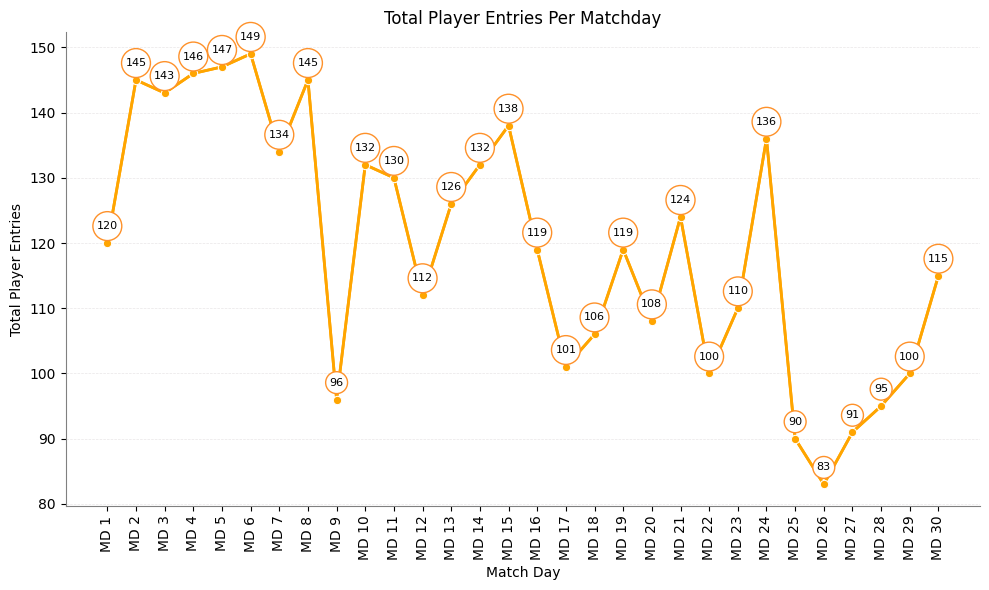

In [144]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [ ]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

In [ ]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

In [ ]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


### Max Metrics

In [ ]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

In [ ]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

## Analysis

### Club Comparison

In [ ]:
club_volume_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
club_volume_mean.round(2)
style_table_for_docs(club_volume_mean)


In [ ]:
club_intensity_mean = (
    df.groupby(['club_for', 'match_day'])[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_work_ratio', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_mean)

In [ ]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin', 'max_acceleration_mss', 'max_deceleration_mss']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max)

### Player High Scores

In [ ]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

In [ ]:
df[df['dec_counts_per_min'] == (df['dec_counts_per_min'].max())]['p_name']

### Comparison by Position Group

In [ ]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

In [ ]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

In [ ]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

In [ ]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

In [ ]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [ ]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

In [ ]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_location)

In [ ]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].mean().round(2)
style_table_for_docs(avg_intensity_by_location_)

In [ ]:
# Prepare data
home_speed = avg_intensity_by_location_.loc['Home', 'top_speed_kmh']
away_speed = avg_intensity_by_location_.loc['Away', 'top_speed_kmh']

# Make radius proportional to top speed (e.g., scale so max speed gets max_radius, min gets min_radius)
min_radius = 0.8
max_radius = 1.1
speeds = np.array([home_speed, away_speed])
norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
home_radius, away_radius = norm_radii

color = '#003b59'

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
ax.axis('off')

# Draw right (Home) semicircle: theta from -pi/2 to pi/2, center at (0,0)
theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
x_home = home_radius * np.cos(theta_home)
y_home = home_radius * np.sin(theta_home)
ax.plot(x_home, y_home, color=color, linewidth=0.5)
if home_radius < away_radius:
    ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

# Draw left (Away) semicircle: theta from pi/2 to 3pi/2, center at (0,0)
theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
x_away = away_radius * np.cos(theta_away)
y_away = away_radius * np.sin(theta_away)
ax.plot(x_away, y_away, color=color, linewidth=0.5)
if away_radius < home_radius:
    ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

# Draw the separating line (y from -max_radius to +max_radius at x=0)
ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

# Place values inside semicircles, centered
ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')
ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')

plt.title('Top Speed (km/hr)', fontsize=12)
plt.show()


### Metric Distribution 

In [ ]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



In [ ]:
# Comparative bar graph for three leagues using vertical lines with large circles on top

leagues = [ 'UCL','PSL', 'UPL']
values = [ 10.94,10.045, 8.54]
palette = sns.color_palette('Set1', len(leagues))
circle_radius = 20

fig, ax = plt.subplots(figsize=(4, 4))

# Draw vertical lines for each league
for i, (league, val, color) in enumerate(zip(leagues, values, palette)):
    ax.vlines(i, 0, val, color=color, linewidth=3, zorder=2)
    ax.plot(i, val, 'o', markeredgecolor=color, markerfacecolor='white', markersize=circle_radius, zorder=3)
    ax.text(i, val, f'{val:.1f}', va='top', ha='center', fontweight='bold',fontsize=7, color='black')

ax.set_xticks(range(len(leagues)))
ax.set_xticklabels(leagues)
ax.set_ylabel('Average Total Distance Covered (km)')
ax.set_xlabel('League')
ax.set_title('Average Total Distance Covered by Players in Different Leagues', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0DCDD')
ax.spines['bottom'].set_color('#E0DCDD')
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)
plt.tight_layout()
plt.show()

## Trend Analysis

In [ ]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

In [ ]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('distance_km', 'Distance (km)'),
    ('sprint_distance_m', 'Sprint Distance (m)'),
    ('player_load', 'Player Load'),
    ('top_speed_kmh', 'Top Speed (km/h)')
]

md15_idx = matchday_order.index('Md15')

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.lineplot(
        data=rolling_avg,
        x='match_day',
        y=col,
        marker='o',
        ax=ax,
        label=f'Average {label}'
    )
    avg_value = rolling_avg[col].mean()
    ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
    # Draw vertical line at MD15
    ax.axvline(md15_idx, color='black', linestyle=':', linewidth=1)
    # Shade area before MD15 (First Round)
    ax.axvspan(-0.5, md15_idx - 0.5, color='skyblue', alpha=0.35)
    # Shade area after and including MD15 (Second Round)
    ax.axvspan(md15_idx - 0.5, md15_idx + 0.5, color='lightgreen', alpha=0.35)
    ax.axvspan(md15_idx + 0.5, len(matchday_order) - 0.5, color='lightgreen', alpha=0.35)
    xticklabels = [str(md).replace('Md', 'MD ') for md in rolling_avg['match_day']]
    ax.set_xticks(range(len(rolling_avg['match_day'])))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(f'{label} Across Match Days')
    ax.set_xlabel('Match Day')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ax.text(md15_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
    ax.text(md15_idx + (len(matchday_order)-md15_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
plt.show()


## Correlation Analysis

In [ ]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df[df['p_name'] == 'Brian Nkuubi'].describe().T

In [ ]:
df[df['p_name'] == 'Bashir Mutanda'].describe().T

In [ ]:
sns.scatterplot(data=df, x='distance_per_min_mmin', y='player_load', alpha=0.6)
plt.xlabel('Distance per Minute (m/min)')
plt.ylabel('Player Load')
plt.title('Scatterplot of Distance per Minute vs Player Load')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()